In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [60]:
df = pd.read_csv("C:\\Users\\olahi\\Desktop\\Linear regression\\Predictive Maintenance of Machines\\data\\CIA-1 Dataset - Dataset (1).csv")

In [61]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Vibration Levels,Operational Hours,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,42.0,20.00,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,52.0,21.00,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,44.0,18.00,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,52.0,10.00,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,44.0,10.00,No Failure
...,...,...,...,...,...,...,...,...,...,...
495,496,H29909,H,297.5,309.3,1459,49.7,45.0,163.91,No Failure
496,497,M15356,M,297.5,309.2,1530,40.0,55.0,164.26,No Failure
497,498,L47677,L,297.4,309.0,1505,39.2,45.0,164.62,No Failure
498,499,L47678,L,297.5,309.1,1611,30.2,34.0,164.97,No Failure


In [62]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      500 non-null    int64  
 1   Product ID               500 non-null    object 
 2   Type                     500 non-null    object 
 3   Air temperature [K]      500 non-null    float64
 4   Process temperature [K]  500 non-null    float64
 5   Rotational speed [rpm]   500 non-null    int64  
 6   Torque [Nm]              500 non-null    float64
 7   Vibration Levels         500 non-null    float64
 8   Operational Hours        500 non-null    float64
 9   Failure Type             500 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 39.2+ KB


In [64]:
df.isna().sum().sort_values(ascending=False)

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Vibration Levels           0
Operational Hours          0
Failure Type               0
dtype: int64

In [65]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Vibration Levels,Operational Hours
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,298.097800,308.576400,1540.494000,39.882800,36.904811,81.106840
std,144.481833,0.563071,0.345372,193.658248,9.768592,9.242797,45.904853
min,1.000000,297.200000,307.900000,1208.000000,4.200000,23.000000,10.000000
25%,125.750000,297.500000,308.300000,1424.750000,33.575000,31.183871,36.202500
50%,250.500000,298.100000,308.500000,1498.000000,40.350000,35.000000,77.575000
75%,375.250000,298.625000,308.800000,1604.500000,46.225000,44.000000,121.097500
max,500.000000,299.100000,309.500000,2874.000000,65.700000,55.000000,165.330000


In [66]:
df_cleaned = df.drop(['UDI'], axis=1)

In [67]:
df_cleaned.head()

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Vibration Levels,Operational Hours,Failure Type
0,M14860,M,298.1,308.6,1551,42.8,42.0,20.0,No Failure
1,L47181,L,298.2,308.7,1408,46.3,52.0,21.0,No Failure
2,L47182,L,298.1,308.5,1498,49.4,44.0,18.0,No Failure
3,L47183,L,298.2,308.6,1433,39.5,52.0,10.0,No Failure
4,L47184,L,298.2,308.7,1408,40.0,44.0,10.0,No Failure


In [68]:
df_cleaned.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Vibration Levels,Operational Hours
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,298.097800,308.576400,1540.494000,39.882800,36.904811,81.106840
std,0.563071,0.345372,193.658248,9.768592,9.242797,45.904853
min,297.200000,307.900000,1208.000000,4.200000,23.000000,10.000000
25%,297.500000,308.300000,1424.750000,33.575000,31.183871,36.202500
50%,298.100000,308.500000,1498.000000,40.350000,35.000000,77.575000
75%,298.625000,308.800000,1604.500000,46.225000,44.000000,121.097500
max,299.100000,309.500000,2874.000000,65.700000,55.000000,165.330000


In [69]:
df_cleaned.shape

(500, 9)

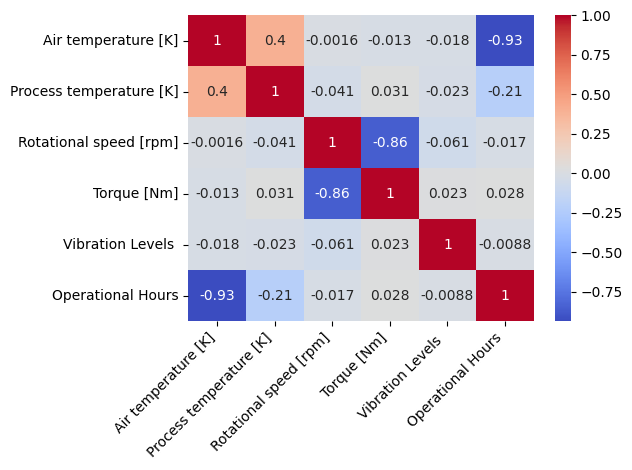

In [70]:
sns.heatmap(
    df_cleaned.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

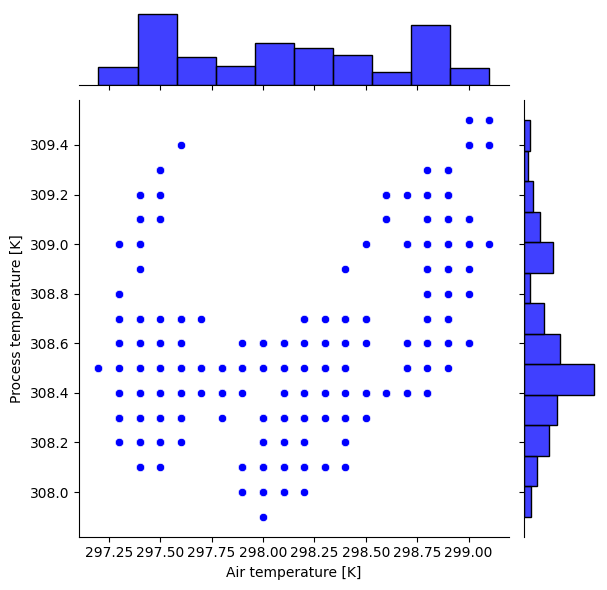

In [71]:
sns.jointplot(x="Air temperature [K]", y="Process temperature [K]", data=df_cleaned, kind="scatter", color="blue")

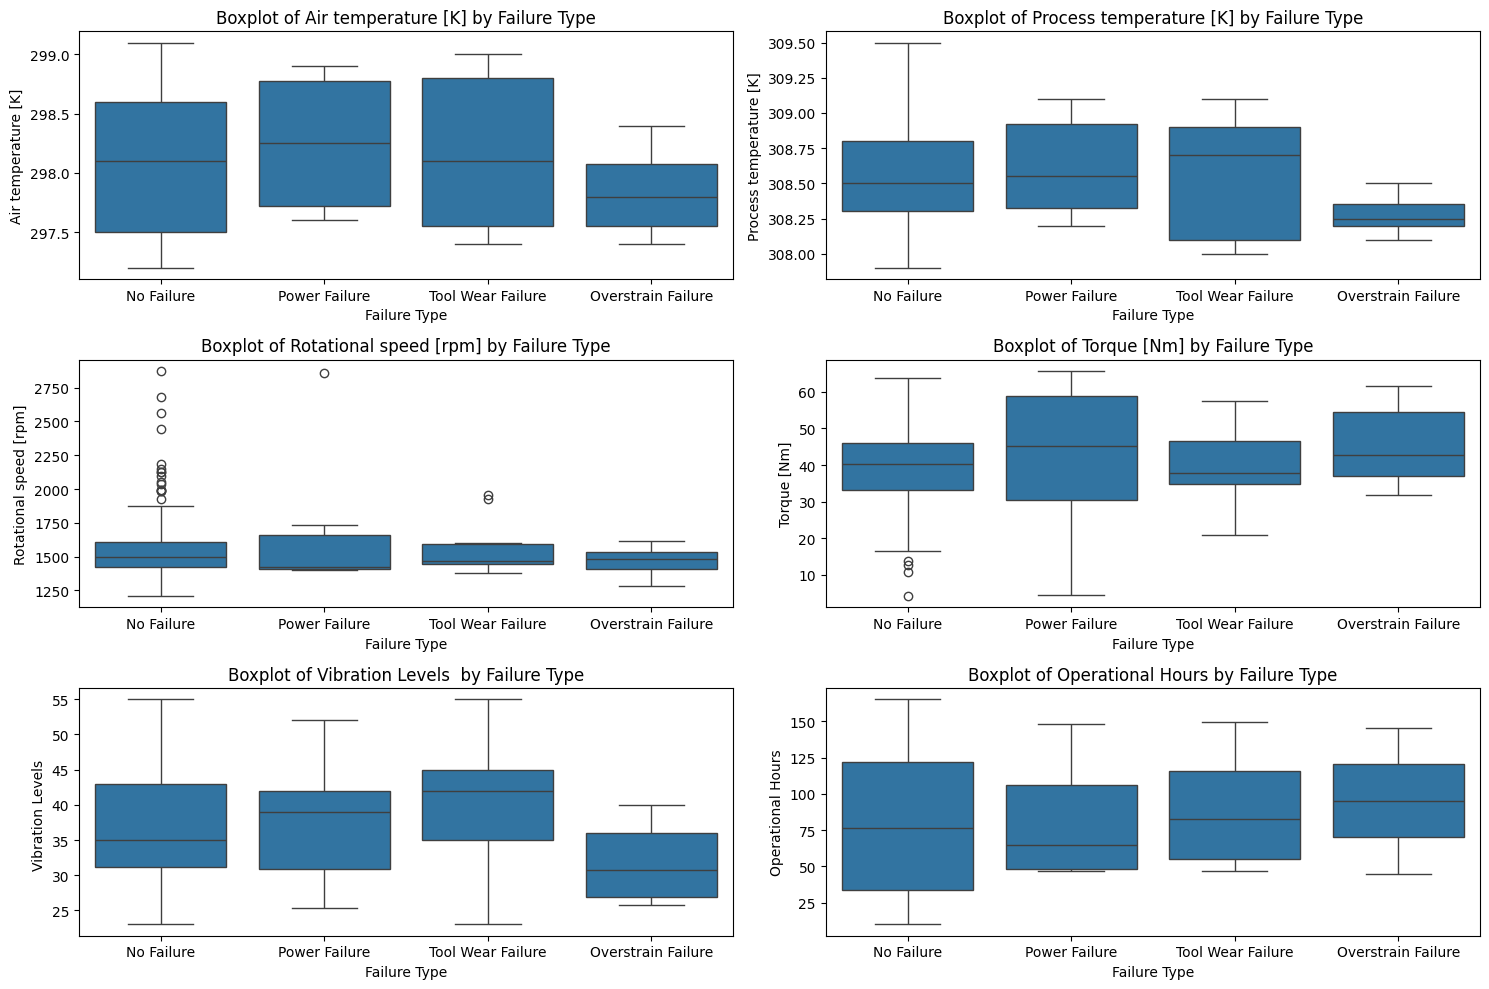

In [72]:
target_col = 'Failure Type'

features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Vibration Levels ",
    "Operational Hours"
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(features):
    if col in df_cleaned.columns:
        sns.boxplot(x=target_col, y=col, data=df_cleaned, ax=axes[i])
        axes[i].set_title(f'Boxplot of {col} by {target_col}')
    else:
        print(f"Column '{col}' not found in the DataFrame.")
plt.tight_layout()            

In [73]:
df_cleaned

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Vibration Levels,Operational Hours,Failure Type
0,M14860,M,298.1,308.6,1551,42.8,42.0,20.00,No Failure
1,L47181,L,298.2,308.7,1408,46.3,52.0,21.00,No Failure
2,L47182,L,298.1,308.5,1498,49.4,44.0,18.00,No Failure
3,L47183,L,298.2,308.6,1433,39.5,52.0,10.00,No Failure
4,L47184,L,298.2,308.7,1408,40.0,44.0,10.00,No Failure
...,...,...,...,...,...,...,...,...,...
495,H29909,H,297.5,309.3,1459,49.7,45.0,163.91,No Failure
496,M15356,M,297.5,309.2,1530,40.0,55.0,164.26,No Failure
497,L47677,L,297.4,309.0,1505,39.2,45.0,164.62,No Failure
498,L47678,L,297.5,309.1,1611,30.2,34.0,164.97,No Failure


In [74]:
df_cleaned["Failure Type"].value_counts()

Failure Type
No Failure            467
Tool Wear Failure      19
Overstrain Failure      8
Power Failure           6
Name: count, dtype: int64

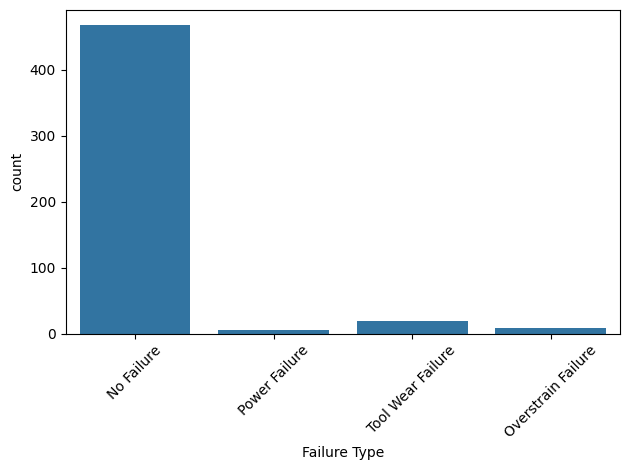

In [75]:
sns.countplot(data=df_cleaned, x="Failure Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

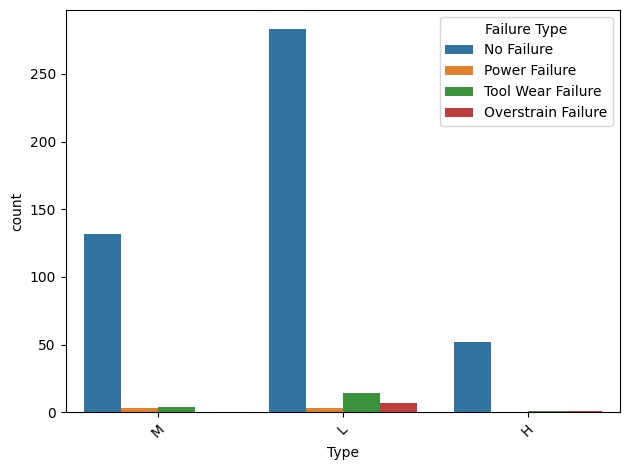

In [76]:
sns.countplot(
    data=df_cleaned,
    x="Type",
    hue="Failure Type"
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

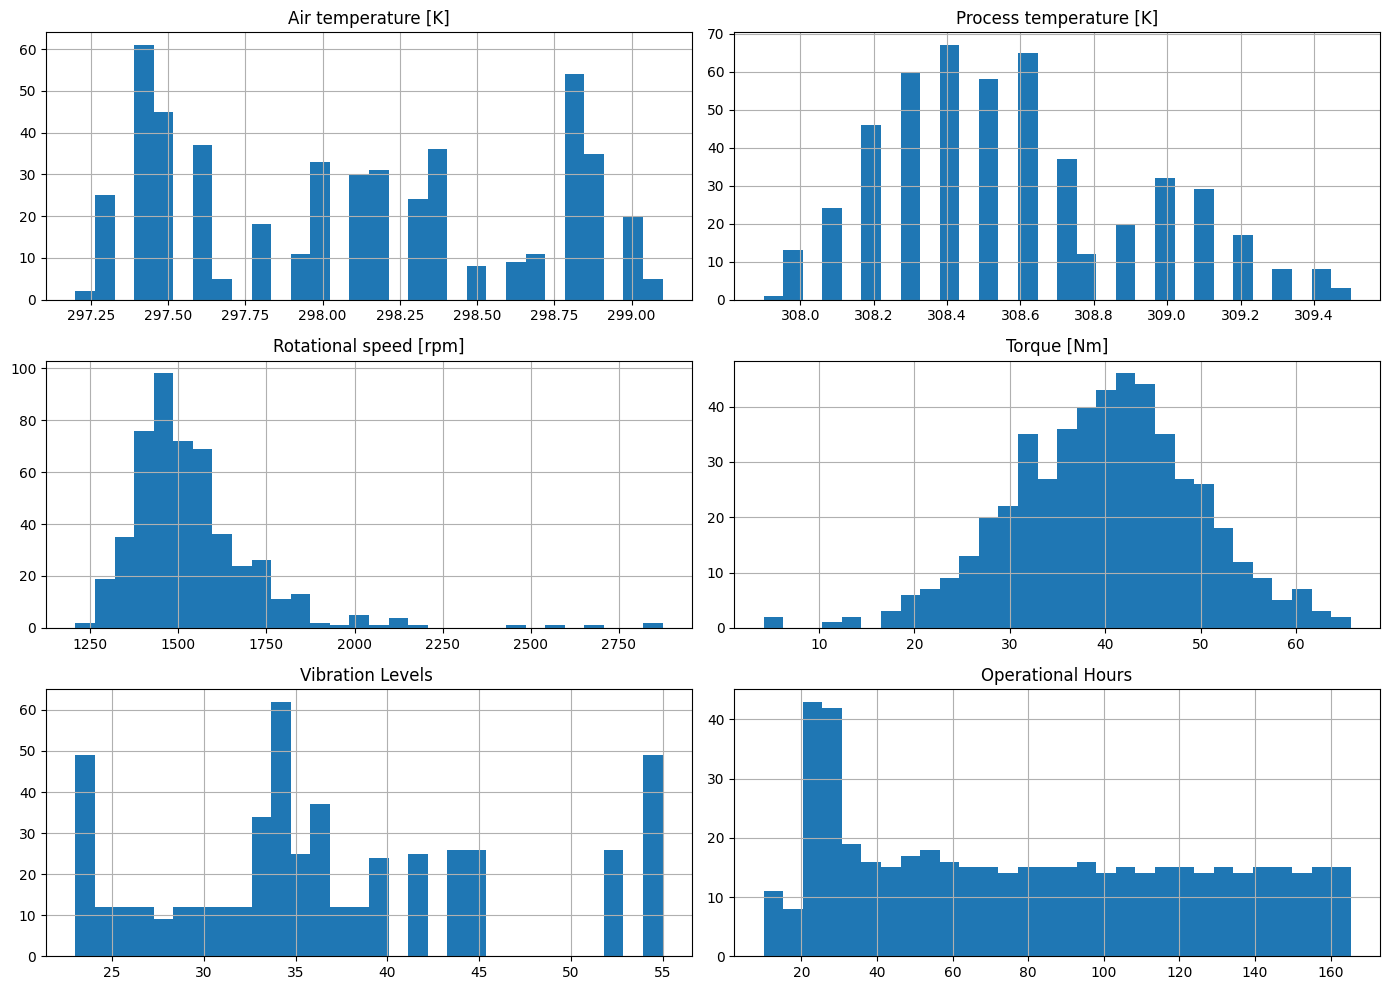

In [77]:
numeric_columns = df_cleaned.select_dtypes(include="number").columns

df_cleaned[numeric_columns].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

In [79]:
df_cleaned.to_csv(
    r"C:\Users\olahi\Desktop\Linear regression\Predictive Maintenance of Machines\data\cleaned_data.csv",
    index=False
)